# 5TF078 Deep Learning Course
## Excercise 4 Sentiment analysis on IMDB
Created by Tomas Nordström, Umeå University

### Revisions:

* 2023-11-24 Initial version based on earlier versions of this Excercise /ToNo
* 2023-12-03 Prepare for release /ToNo
* 2023-12-04 Work around a bug that made installing KerasNLP force a non-GPU version of tensorflow /ToNo
* 2023-12-07 Since two days there is is a bug in keras-nlp.git "No module named 'keras_hub.models.electra'", so an updated installation method is implemented. /ToNo
* 2024-01-31 A new way of installing keras_hub, as the previous one began to crash in the last weeks.
* 2024-03-24 Updated tests for Kaggle. /Tomas
* 2024-05-05 Added missing "import time" & "import os"; Forced a loading of dev versions of Keras/TF as current version do not handle LSTM well. /Tomas
* 2024-11-29 Updated the VG part (removed LSTM with a pretrained word2vec). /Tomas
* 2024-12-06 Removed the import of "nightly" versions as it is no longer needed. /Tomas
* 2025-04-27 Added AI-declaration. /Tomas
* 2025-05-01 Switch to keras-hub instead of keras-nlp. /Tomas
* 2025-05-01 Made an update to tensorflow to avoid a bug in the CNN part of this exercise. /Tomas
* 2025-12-04 Removed the use of SimpleRNN. Made it clearer what sequence_length is used. /Tomas
* 2025-12-12 Fixed two places where I missed to specify sequence_length in the name preprocessing_layer_500. /Tomas

Much of this is based on the KerasHub (when it was KerasNLP) getting started documentation:
https://keras.io/keras_hub/getting_started/

Other code examples used:
* https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/first_edition/6.2-understanding-recurrent-neural-networks.ipynb
* https://keras.io/examples/nlp/fnet_classification_with_keras_hub/
* https://www.tensorflow.org/text/tutorials/text_classification_rnn
* https://keras.io/examples/nlp/text_classification_from_scratch/


### Akinyi M. Ocholla

# First we initilize our Python environment

In [3]:
import sys
import os
import time

### Is this notebook running on Colab?
IS_COLAB = "google.colab" in sys.modules

### Is this notebook running on Kaggle?
# Fool Kaggle into making kaggle_secrets avaiable
try:
    import kaggle_secrets
except ImportError as e:
    pass
# Now we can test for Kaggle
IS_KAGGLE = "kaggle_secrets" in sys.modules

In [4]:
# To avoid a bug we install a newer version of tensorflow and keras
import tensorflow as tf
from IPython.display import display, Javascript
import signal
tfversion = tf.__version__
print('TensorFlow version:', tfversion)
if (IS_COLAB or IS_KAGGLE):
    major, minor, *_ = map(int, tfversion.split('.'))

    if (major, minor) < (2, 19):
        print("TensorFlow version is below 2.19. Upgrading to the latest...")
        !pip install -q --upgrade keras tensorflow tensorflow_text keras-hub
        print("You need to restart the runtime now!")
        sys.exit() # should have been a dialog to restart, but I do not know how

TensorFlow version: 2.20.0


In [5]:
# Set up Keras backend
os.environ["KERAS_BACKEND"] = "tensorflow" # Also tensorflow,jax,pytorch for Keras 3.0

# Make TF less noisy
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # or any {'0', '1', '2'}

# Import Keras/TF libraries
import keras
print('Keras version:', keras.__version__)

import tensorflow as tf
print('TensorFlow version:', tf.__version__)

Keras version: 3.13.1
TensorFlow version: 2.20.0


In [6]:
# Test for GPU and determine what GPU we have
import platform
import subprocess
gpu_devices = tf.config.list_physical_devices('GPU')

gpu_name = tf.test.gpu_device_name()
if gpu_name != '':
    print('TF-GPU-devname:',tf.test.gpu_device_name())
    sys_details = tf.sysconfig.get_build_info()
    physical_devices = tf.config.list_physical_devices('GPU')
    print("Num GPUs:", len(physical_devices))
    if platform.system() == "Darwin":
        print('GPU on Mac!')
    else:
        cuda_version = sys_details["cuda_version"]
        print('TF-cuda version:',cuda_version)
        if len(physical_devices)>0:
            process = subprocess.Popen(['nvidia-smi','-L'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
            print(process.communicate())
        # If possible to run code with 16 bits float instead of 32 bits float, this code activates such functionality:
        if gpu_devices:
            details = tf.config.experimental.get_device_details(gpu_devices[0])
            compute_capability=details.get('compute_capability')
            print("Compute capability:",compute_capability)
            if compute_capability[0]>6:
                print("Turning on mixed_float16")
                policy = keras.mixed_precision.Policy('mixed_float16')
                keras.mixed_precision.set_global_policy(policy)
else:
    print('TF-device CPU')

TF-GPU-devname: /device:GPU:0
Num GPUs: 1
TF-cuda version: 12.5.1
(b'GPU 0: Tesla P100-PCIE-16GB (UUID: GPU-76ff9c64-565d-0747-fdb1-de144ca34ad6)\n', b'')
Compute capability: (6, 0)


I0000 00:00:1769698128.529449    1915 gpu_device.cc:2020] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1769698128.531611    1915 gpu_device.cc:2020] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


NOTE: Currently (2025-12-04) this code is not working correctly for sequence_length=500 on my Mac M4 and potentially also other architectures, so be aware if running locally. But it seems to work OK in Colab.

In [7]:
# Helper libraries
import numpy as np
import pandas as pd

# Matlab plotting
import matplotlib
import matplotlib.pyplot as plt

# Load the data

The IMDb dataset consists of 50,000 movie reviews in English
(25,000 for training, 25,000 for testing) extracted from the famous Internet Movie Database, along with a simple binary target for each review indicating whether it is negative (0) or positive (1).

There are many alternatives to get the data:
* Use the Keras built in [IMDB database](https://keras.io/api/datasets/imdb/) from keras.
* Use the TensorFlow Datasets library for [IMDB reviews](https://www.tensorflow.org/datasets/catalog/imdb_reviews)
* Or as we are going to do, read the [orginal dataset](http://ai.stanford.edu/~amaas/data/sentiment/)

We use to orginal data to see how one can read data (text) files from directories directly. How one can do preprocessing on datasets. The raw data is also preferred when we later want to work with BERT as a transfer learning model. (The Keras data have already preprocessed words into integers.)

In [8]:
# Reading the database from the source
# following https://keras.io/guides/keras_hub/getting_started/
if not os.path.exists('./aclImdb_v1.tar.gz'):
  !curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
  !tar -xf aclImdb_v1.tar.gz
  !# Remove unsupervised examples
  !rm -r aclImdb/train/unsup

print(os.listdir("./aclImdb"))
print(os.listdir("./aclImdb/train"))
print(os.listdir("./aclImdb/test"))

with open("./aclImdb/train/pos/4242_9.txt") as f:
  print (f'Example of a postive review: {f.read()}')

['README', 'test', 'train', 'imdbEr.txt', 'imdb.vocab']
['labeledBow.feat', 'neg', 'urls_neg.txt', 'urls_pos.txt', 'pos', 'urls_unsup.txt', 'unsupBow.feat']
['labeledBow.feat', 'neg', 'urls_neg.txt', 'urls_pos.txt', 'pos']
Example of a postive review: I read the book and saw the movie. Both excellent. The movie is diamond among coals during this era. Liebman and Selby dominate the screen and communicate the intensity of their characters without flaw. This film should have made them stars. Shame on the studio for not putting everything they had behind this film. It could have easily been a franchise. Release on DVD is a must and a worthy remake would revive this film. Look for it in your TV guide and if you see it listed, no matter how late, watch it. You won't be disappointed. Do yourself another favor - read the book (same title). It'll blow you away. Times have changed dramatically since those days, or at least we like to think they have.


In [9]:
batch_size = 32

# Load directories of text into our datasets using https://keras.io/api/data_loading/text/
raw_imdb_train_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/train",
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=1337,
)
raw_imdb_val_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/train",
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=1337,
)
raw_imdb_test_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/test", batch_size=batch_size
)

print(f"Number of batches in raw_imdb_train_ds: {raw_imdb_train_ds.cardinality()}")
print(f"Number of batches in raw_imdb_val_ds: {raw_imdb_val_ds.cardinality()}")
print(f"Number of batches in raw_imdb_test_ds: {raw_imdb_test_ds.cardinality()}")

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


I0000 00:00:1769698137.848983    1915 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.
Number of batches in raw_imdb_train_ds: 625
Number of batches in raw_imdb_val_ds: 157
Number of batches in raw_imdb_test_ds: 782


In [10]:
# Let's print a few samples.
for text_batch, label_batch in raw_imdb_train_ds.take(1):
    for i in range(3):
        print(text_batch.numpy()[i])
        print(label_batch.numpy()[i])

b'I\'ve seen tons of science fiction from the 70s; some horrendously bad, and others thought provoking and truly frightening. Soylent Green fits into the latter category. Yes, at times it\'s a little campy, and yes, the furniture is good for a giggle or two, but some of the film seems awfully prescient. Here we have a film, 9 years before Blade Runner, that dares to imagine the future as somthing dark, scary, and nihilistic. Both Charlton Heston and Edward G. Robinson fare far better in this than The Ten Commandments, and Robinson\'s assisted-suicide scene is creepily prescient of Kevorkian and his ilk. Some of the attitudes are dated (can you imagine a filmmaker getting away with the "women as furniture" concept in our oh-so-politically-correct-90s?), but it\'s rare to find a film from the Me Decade that actually can make you think. This is one I\'d love to see on the big screen, because even in a widescreen presentation, I don\'t think the overall scope of this film would receive its

Note that the raw text contains HTML break tags of the form "\<br /\>"!

We want to remove them later on.

In [11]:
# The test sentences in this exercise
test_sentences = [
  "That movie was absolutely awful",
  "The acting was a bit lacking",
  "The film was creative and surprising",
  "Absolutely fantastic!",
  "This movie is not worth the money",
  "The only positive thing with this movie is the music"
]

# Do Data Preprocessing

## Set it up

In [12]:
# Model constants
embedding_dim = 32    # The dimensionality of the embedding vectors
vocab_size = 10000    # Maximum number of words to keep in the vocabulary

In [13]:
# We will now convert the text to lowercase and remove html stuff
# Based on https://keras.io/examples/nlp/text_classification_from_scratch/

import string
import re

# Having looked at our data above, we see that the raw text contains HTML break
# tags of the form '<br />'. These tags will not be removed by the default
# standardizer (which doesn't strip HTML). Because of this, we will need to
# create a custom standardization function.
def custom_standardization(input_data):
    lowercase = tf.strings.lower(input_data)
    stripped_html = tf.strings.regex_replace(lowercase, "<br />", " ")
    return tf.strings.regex_replace(
        stripped_html, f"[{re.escape(string.punctuation)}]", ""
    )

In [14]:
def create_preprocessed_datasets(raw_train_ds, raw_val_ds, raw_test_ds, vocab_size, sequence_length, custom_standardization):
    # Instantiate our text vectorization layer.
    preprocessing_layer = keras.layers.TextVectorization(
        standardize=custom_standardization,
        max_tokens=vocab_size,
        output_mode="int",
        output_sequence_length=sequence_length,
    )

    # Adapt the layer to the training text to create the vocabulary.
    text_ds_for_adapt = raw_train_ds.map(lambda x, y: x)
    preprocessing_layer.adapt(text_ds_for_adapt)

    # Define a function to prepare the text in a dataset batch
    def preprocessing_text_with_layer(text, label):
        text = tf.expand_dims(text, -1)
        return preprocessing_layer(text), label

    # Preprocess the datasets.
    train_ds_processed = raw_train_ds.map(preprocessing_text_with_layer)
    val_ds_processed = raw_val_ds.map(preprocessing_text_with_layer)
    test_ds_processed = raw_test_ds.map(preprocessing_text_with_layer)

    # Do async prefetching / buffering of the data for best performance on GPU.
    train_ds_processed = train_ds_processed.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    val_ds_processed = val_ds_processed.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    test_ds_processed = test_ds_processed.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

    return train_ds_processed, val_ds_processed, test_ds_processed, preprocessing_layer, preprocessing_text_with_layer

In [15]:
# Function to extract sequence length for a particular dataset
def get_sequence_length_from_dataset(dataset):
    for text_batch, label_batch in dataset.take(1):
        first_text_tensor = text_batch[0]
        return first_text_tensor.shape[0]
    return None # In case the dataset is empty

In [16]:
# Create datasets for sequence_length = 100 (initial setup)
current_sequence_length = 100 # Reset to 100 for this first set of datasets
train_ds_100, val_ds_100, test_ds_100, preprocessing_layer_100, preprocessing_text_100 = create_preprocessed_datasets(
    raw_imdb_train_ds, raw_imdb_val_ds, raw_imdb_test_ds,
    vocab_size, current_sequence_length, custom_standardization
)

current_sequence_length_500 = 500 # Also make a dataset with 500 elements
train_ds_500, val_ds_500, test_ds_500, preprocessing_layer_500, preprocessing_text_500 = create_preprocessed_datasets(
    raw_imdb_train_ds, raw_imdb_val_ds, raw_imdb_test_ds,
    vocab_size, current_sequence_length_500, custom_standardization
)

In [17]:
# Show how to get the vocabulary
voc = preprocessing_layer_500.get_vocabulary()
print(voc[:8])
word_index = dict(zip(voc, range(len(voc))))

['', '[UNK]', 'the', 'and', 'a', 'of', 'to', 'is']


# Using recurrent neural networks (RNN) for text

This corresponds to Geron's Chapter 16 - Natural Language Processing with RNNs and Attention, and [the corresponding code](https://github.com/ageron/handson-ml3/blob/main/16_nlp_with_rnns_and_attention.ipynb).

We are here only working on word level (not character level as in the beginning of Chapter 16)

## The Embedding Layer

The [Embedding](https://keras.io/api/layers/core_layers/embedding/) Layer turns positive integers (indexes) into dense vectors of fixed size.

Here each input integer corresponds to a word in our vocabulary (typical size between 1000 and 30000, and 10000 in this case), and is mapped into a short and dense vector (typical size 32-512). In a similar way as the word2vec mapping in the first part of this exercise. However, this mapping is initialized as a random mapping for each model, that then is adjusted during training.

## A commonly used RNN Layer: LSTM

In keras there are a number of [RNN layers](https://keras.io/api/layers/recurrent_layers/). The most basic one is the [SimpleRNN](https://keras.io/api/layers/recurrent_layers/simple_rnn/) which is a fully-connected RNN where the output is to be fed back as the new input.

But as the performance is poor and it is inefficiently implemented on some platforms, we will base most of these experiment on the Long Short-Term Memory [LSTM layer](https://keras.io/api/layers/recurrent_layers/lstm/) instead.

The RNN layers process batches of sequences, that is, it takes inputs of shape `(batch_size, timesteps, input_features)`.
Like all recurrent layers in Keras, `LSTM` can be run in two different modes: it can return either the full sequences of successive
outputs for each timestep (a 3D tensor of shape `(batch_size, timesteps, output_features)`), or it can return only the last output for each
input sequence (a 2D tensor of shape `(batch_size, output_features)`). These two modes are controlled by the `return_sequences` constructor
argument. Let's take a look at some examples:


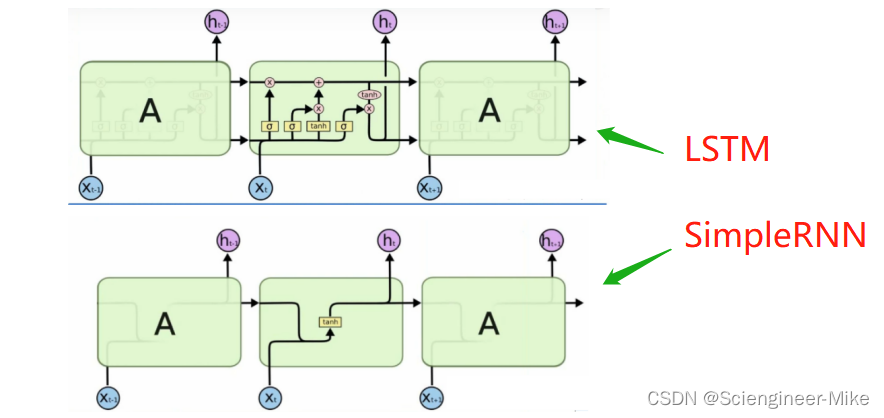

Here the small yellow boxes actually are a weight matrix multiplication followed by a non-linear function (indicated in yellow box).

In [18]:
sequence_length = 500 # The length of each input sequence after padding/truncation
input_shape = (sequence_length,) # input_tokens_ex.shape #

train_ds = train_ds_500
val_ds = val_ds_500
test_ds = test_ds_500

In [19]:
model = keras.models.Sequential()
model.add(keras.Input(shape=input_shape))
model.add(keras.layers.Embedding(vocab_size, embedding_dim, mask_zero=True))
model.add(keras.layers.SimpleRNN(32)) ## return_sequences=False (is default)
model.add(keras.layers.Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

For this SimpleRNN we see it has 2080 parameters, coming from the single weight matrix in such layer (32+32+1)*32 = 2080, the input dimension is a concatenation of the input (x)+the memory (h)+bias.

In [20]:
model = keras.models.Sequential()
model.add(keras.Input(shape=input_shape))
model.add(keras.layers.Embedding(vocab_size, embedding_dim, mask_zero=True))
model.add(keras.layers.LSTM(32)) ## return_sequences=False (is default)
model.add(keras.layers.Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

For this LSTM model we see it has 8320 parameters, actually coming from the four weight matrices in such layer 4*(32+32+1)*32 = 8320, the input dimension for each of these weight matrices are again a concatenation of the input (x)+the memory (h)+bias.

In [21]:
model = keras.models.Sequential()
model.add(keras.Input(shape=input_shape))
model.add(keras.layers.Embedding(vocab_size, embedding_dim, mask_zero=True))
model.add(keras.layers.LSTM(32, return_sequences=True))
model.add(keras.layers.Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 500, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500, 1)         │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

It is sometimes useful to stack several recurrent layers one after the other in order to increase the representational power of a network.
In such a setup, you have to get all *intermediate* layers to return full sequences:

In [22]:
model = keras.models.Sequential()
model.add(keras.Input(shape=input_shape))
model.add(keras.layers.Embedding(vocab_size, embedding_dim, mask_zero=True))
model.add(keras.layers.LSTM(32, return_sequences=True))
model.add(keras.layers.LSTM(32, return_sequences=True))
model.add(keras.layers.LSTM(32, return_sequences=True))
model.add(keras.layers.LSTM(32))  # This last layer only returns the last outputs.
model.add(keras.layers.Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 500, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 500, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 500, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,313 (1.35 MB)

 Trainable params: 353,313 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

# Test of a simple LSTM model
Here we want to understand the influence of sequence_length and masking

## Helper function to compile and train a model

In [23]:
def compile_and_fit(model, train_ds, val_ds, epochs=10, patience=3, verbose=1):
  print(f'Training {model.name}')
  print(f"Using a sequence length = {get_sequence_length_from_dataset(train_ds)}")
  model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=2.5e-4),
                loss='binary_crossentropy',
                metrics=['acc'],)

  early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=patience,restore_best_weights = True)

  start = time.time()
  history = model.fit(train_ds,
                      epochs=epochs,
                      validation_data=val_ds,
                      verbose = verbose,
                      callbacks=[early_stopping])
  end = time.time()
  print(f"Time to run: {end - start:.1f}",)
  return model, history

## Now train your first RNN model for sentiment analysis

Let's train a simple recurrent network using an `Embedding` layer and a single `LSTM` layer:

In [24]:
model = keras.Sequential([
    # Set up input shape
    keras.Input(shape=input_shape, dtype="int32"),
    # Next, we add a layer to map those vocab indices into a space of dimensionality 'embedding_dim'.
    keras.layers.Embedding(vocab_size, embedding_dim, mask_zero=True),
    # Our RNN model
    keras.layers.LSTM(32),
    # End part for classification
    keras.layers.Dense(1,activation='sigmoid')
],name='LSTM32')

In [25]:
model,history = compile_and_fit(model, train_ds, val_ds, patience=2)

Training LSTM32
Using a sequence length = 500
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - acc: 0.6258 - loss: 0.6329 - val_acc: 0.7834 - val_loss: 0.4720
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - acc: 0.8486 - loss: 0.3713 - val_acc: 0.8610 - val_loss: 0.3360
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - acc: 0.8942 - loss: 0.2757 - val_acc: 0.8678 - val_loss: 0.3537
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - acc: 0.9130 - loss: 0.2362 - val_acc: 0.8766 - val_loss: 0.2995
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - acc: 0.9231 - loss: 0.2109 - val_acc: 0.8682 - val_loss: 0.3663
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - acc: 0.9325 - loss: 0.1914 - val_acc: 0.8726 - val_loss: 0.3541
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 4.
Time to run: 69.7


Let's display the training and validation loss and accuracy:

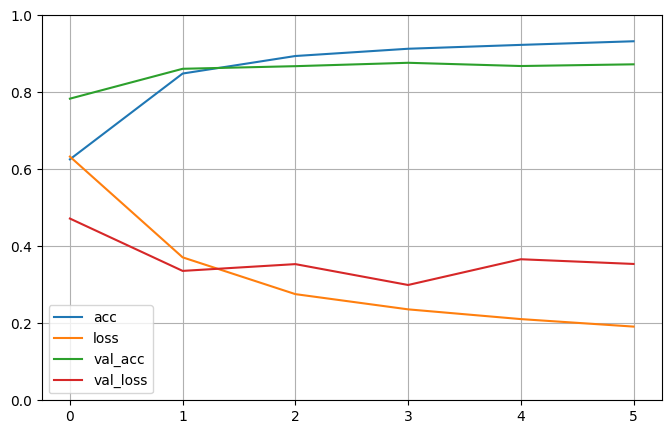

In [26]:
# Plot training history
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [27]:
test_loss, test_acc =  model.evaluate(test_ds, verbose=0)
print(f'Model {model.name}, len={get_sequence_length_from_dataset(test_ds)}, test accuracy: {test_acc:.3f}')

Model LSTM32, len=500, test accuracy: 0.877


Unfortunately, our small LSTM network does not perform very well. Part of the problem is that our inputs only consider the first 100 words rather the full sequences.

# ‽ Frågor
Undersök hur Sekvenslängd och Mask påverkar prestandan
* Notera vilken testnoggrannhet du får för detta fall (sequence_length=100)
* Gå nu upp och ändra sequence_length till 500, vilken testnoggrannhet får du då? Vad kan vara skälet till detta beteende?
* Pröva sedan med att sätta 'mask_zero=True' i Embedding-lagret
* Kompletera sedan bilden med att köra med 'mask_zero=True' och sequence_length=100

Dvs du ska göra fyra körningar sequence_length=\{100,500\} och mask_zero=\{True, False\}. Redovisa gärna som en tabell.

Titta även på träningskurvorna, går det fort för modellen att överträna? Vad händer om du halverar learning_rate (med träningstid, testnoggrannhet, träningskurvorna)?

### STUDENTSVAR (FRÅGOR):
* With sequence_length=100 we get a test_accuracy of 0.813 and validation_loss 0.399, validation_accuracy at 0.824 and an accuracy of 0.862 at epoch 3.
* With mask_zero=False,sequence_length=100 we get a test_accuracy of 0.803 and validation_loss 0.422, validation_accuracy at 0.811 and an accuracy of 0.817 at epoch 2.
* With mask_zero=True,sequence_length=100 we get a test_accuracy of 0.811 and validation_loss 0.402, validation_accuracy at 0.818 and an accuracy of 0.834 at epoch 4.
* With mask_zero=False, sequence_length=500, test_accuracy is 0.500, validation_loss 0.692, validation_accuracy at 0.509, accuracy at 0.509. It seems to overtrain immediately.
* With mask_zero=True, sequence_length=500, test_accuracy is 0.875, validation_loss 0.348, validation_accuracy at 0.874, accuracy at 0.910. 
* **Test_accuracy table. learning rate 5e-4**
*                  **100****500**
*  **Mask_zero_False**       **0.803**        **0.500**
*  **Mask_zero_True**        **0.811**        **0.875**
* The modells overtrain very quickly - already by epoch 2 or 3. The LSTM with seq_length 100 performs almost as good with Mask_zero False as with True. With seq_length 500 and Mask_zero True we achieve the best test_accuracy of 0.875.
* When I halv the learning_rate from 5e-4 to 2,5e-4, 10 epochs and seq_length 100 I get a test_accuracy of 0.814 and with a seq_length of 500, the test_accuracy goes up to 0.883.
*  **Test_accuracy table. learning rate 2.5e-4**
*                  **100****500**
*  **Mask_zero_True**        **0.814**        **0.883**

## Ett LSTM-exempel i Keras

Låt oss nu gå vidare med sequence_length=500, och mask_zero=True. Först vår lilla modell med 32 noder.

In [28]:
# Model constants
sequence_length = 500 # The length of each input sequence after padding/truncation
input_shape = (sequence_length,) # input_tokens_ex.shape #


# Set up the datasets for this sequence length
train_ds = train_ds_500
val_ds = val_ds_500
test_ds = test_ds_500

In [29]:
model = keras.Sequential([
    keras.Input(shape=input_shape, dtype="int32"),
    keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True),
    keras.layers.LSTM(32),
    keras.layers.Dense(1,activation='sigmoid')
],name='LSTM32')

In [30]:
model.summary()

Model: "LSTM32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model,history = compile_and_fit(model, train_ds, val_ds,  patience=2)


Training LSTM32
Using a sequence length = 500
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - acc: 0.6120 - loss: 0.6453 - val_acc: 0.6754 - val_loss: 0.6144
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - acc: 0.8395 - loss: 0.4026 - val_acc: 0.8548 - val_loss: 0.3443
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - acc: 0.8872 - loss: 0.2914 - val_acc: 0.8494 - val_loss: 0.3530
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - acc: 0.9089 - loss: 0.2439 - val_acc: 0.8390 - val_loss: 0.3772
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.
Time to run: 44.7


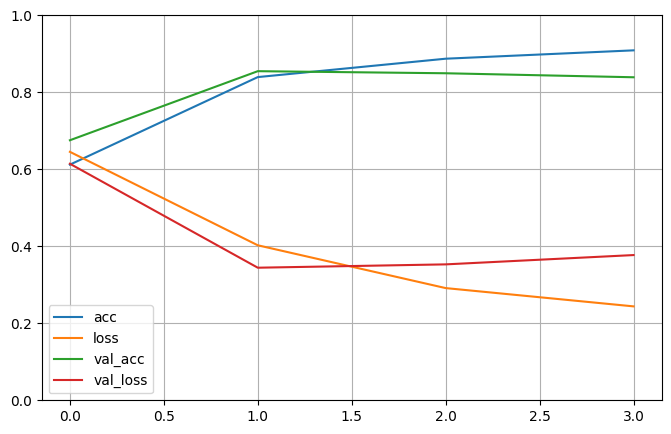

In [32]:
# Plot training history
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [33]:
test_loss, test_acc =  model.evaluate(test_ds, verbose=0)
print(f'Model {model.name}, len={get_sequence_length_from_dataset(test_ds)}, test accuracy: {test_acc:.3f}')

Model LSTM32, len=500, test accuracy: 0.860


Notera att vi nu har mycket bättre resultat och modellen är fortfarande liten.

## Fråga
* Hur många parametrar har LSTM-lagret? Är det beroende av sequence length?
* Hur många har embedding lagret? Är det beroende av sequence length?

## STUDENTSVAR (Frågor):
* Parameters in an LSTM is calculated by 4 gates *  (( x  +  h ) ×  h  + h ),   x  is the input dimension, h  is the number of LSTM units / cells / latent space / output dimension:
*  4*(32+32+1)*32 = 8320 parameters. It does not depend on sequence_length.
*  Embedding layer has 320 000 parameters i.e vocubulary_size 10,000 * embedding_size 32 = 320,000. It is not dependent on sequence length.

## Testing with Test sentences

In [34]:
# See what the model say about the test sentences
tspred = model.predict(preprocessing_layer_500(test_sentences))
for ix in range(len(tspred)):
  print(f'{tspred[ix,0]:.2f} -- {test_sentences[ix]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
0.38 -- That movie was absolutely awful
0.48 -- The acting was a bit lacking
0.55 -- The film was creative and surprising
0.57 -- Absolutely fantastic!
0.44 -- This movie is not worth the money
0.42 -- The only positive thing with this movie is the music


## Frågor:
* Känns modellens bedömning korrekt?
* Notera att förlustfunktionen strävar efter tvärsäkra beslut (0 eller 1), men vill man verkligen ha en tvärsäker modell?

Att fundera på (osäkert ifall det finns ett tydligt svar på denna fråga).
* Hur skulle man kunna skapa och träna en modell att ha mer nyanserade svar?

## STUDENTSVAR (Analys):
Yes the model is fairly correct. I dont think the modell can be absolutely correct because some sentiments are a bit contradictory or a mix of good and bad and so it is difficult to actually give it an absolute value. But I'm a little surprised that a rating of 'Absolutely fantastic' only gets a test_pred of 0.66 and not higher.

One can create a modell that can give a neutral response i.e. neither good nor bad sentiment.


# ‽ Uppgift
Utforska fler LSTM modeller (Om du får problem med körtiderna så kan du för denna del använda sekvenslängd 100 och bara för den absolut bästa modellen köra en gång med längd 500 så vi får något att jämföra med i följande delar).
* LSTM(128) med 128 noder, Två lager av LSTM(2L32), en en bidirektionell LSTM BiLSTM(32) och analysera dessa resultat.
* Hitta en "bästa" modell att gå vidare med.
* Undersök ifall det finns någon regularisering som förbättrar testnoggrannheten (notera att det finns speciella regulariseringar för LSTM modeller som du också kan pröva).

* Testa din bästa RNN-modell på våra testmeningar, finns det några meningar som modellen är osäker på, och i så fall, är det förståeligt?


## STUDENTSVAR (Kod):

In [35]:
# Code where you evaluate all these variants of LSTM models
# Model constants
sequence_length = 500 # The length of each input sequence after padding/truncation
input_shape = (sequence_length,) # input_tokens_ex.shape #


# Set up the datasets for this sequence length
train_ds = train_ds_500
val_ds = val_ds_500
test_ds = test_ds_500

In [36]:
# LSTM 128 
model128 = keras.Sequential([
    keras.Input(shape=input_shape, dtype="int32"),
    keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True),
    keras.layers.LSTM(128),
    keras.layers.Dense(1,activation='sigmoid')
],name='LSTM128')

In [37]:
model128.summary()

Model: "LSTM128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,561 (1.54 MB)

 Trainable params: 402,561 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model128,history = compile_and_fit(model128, train_ds, val_ds,  patience=3)

Training LSTM128
Using a sequence length = 500
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - acc: 0.6490 - loss: 0.6021 - val_acc: 0.7906 - val_loss: 0.4598
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - acc: 0.8583 - loss: 0.3535 - val_acc: 0.8682 - val_loss: 0.3097
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - acc: 0.8931 - loss: 0.2732 - val_acc: 0.8754 - val_loss: 0.2964
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - acc: 0.9118 - loss: 0.2392 - val_acc: 0.8814 - val_loss: 0.2989
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - acc: 0.9241 - loss: 0.2098 - val_acc: 0.8740 - val_loss: 0.3477
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - acc: 0.9306 - loss: 0.1956 - val_acc: 0.8720 - val_loss: 0.4011
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
Time to run: 86.5


In [39]:
test_loss, test_acc =  model.evaluate(test_ds, verbose=0)
print(f'Model {model128.name}, len={get_sequence_length_from_dataset(test_ds)}, test accuracy: {test_acc:.3f}')

Model LSTM128, len=500, test accuracy: 0.860


In [40]:
# LSTM 2 layers 32

model_2_32 = keras.Sequential([
    keras.Input(shape=input_shape, dtype="int32"),
    keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.LSTM(32),
    keras.layers.Dense(1,activation='sigmoid')
],name='LSTM32')

In [41]:
model_2_32.summary()

Model: "LSTM32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 500, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 336,673 (1.28 MB)

 Trainable params: 336,673 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model_2_32,history = compile_and_fit(model_2_32, train_ds, val_ds,  patience=3)

Training LSTM32
Using a sequence length = 500
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - acc: 0.6747 - loss: 0.5692 - val_acc: 0.8276 - val_loss: 0.4012
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - acc: 0.8637 - loss: 0.3349 - val_acc: 0.8456 - val_loss: 0.3618
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - acc: 0.8996 - loss: 0.2661 - val_acc: 0.8612 - val_loss: 0.3353
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - acc: 0.9173 - loss: 0.2286 - val_acc: 0.8640 - val_loss: 0.3325
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - acc: 0.9254 - loss: 0.2056 - val_acc: 0.8526 - val_loss: 0.3846
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - acc: 0.9340 - loss: 0.1890 - val_acc: 0.8784 - val_loss: 0.3107
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - acc: 0.9406 - loss: 0.1711 - val_acc: 0.8478 - val_loss: 0.4634
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - acc: 0.9467 - loss: 0.1609 - val_acc: 0.8496 - val_loss: 0

In [43]:
test_loss, test_acc =  model_2_32.evaluate(test_ds, verbose=0)
print(f'Model {model_2_32.name}, len={get_sequence_length_from_dataset(test_ds)}, test accuracy: {test_acc:.3f}')

Model LSTM32, len=500, test accuracy: 0.875


In [44]:
# LSTM BiLSTM(32)  #  Consulted a Geeks for Geeks homepage for Bidirectional Model since the bidirectional translation Model in chapter 16 was confusing 
# https://www.geeksforgeeks.org/deep-learning/what-is-embedding-layer/
modelBiLSTM = tf.keras.Sequential([
    keras.Input(shape=input_shape, dtype="int32"),
    keras.layers.Embedding(vocab_size, 64, mask_zero=True),
    keras.layers.Bidirectional(keras.layers.LSTM(32, return_sequences=True)),
    keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1)
])

modelBiLSTM.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 500, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 500, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,889 (2.65 MB)

 Trainable params: 693,889 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
modelBiLSTM,history = compile_and_fit(modelBiLSTM, train_ds, val_ds,  patience=3)

Training sequential_4
Using a sequence length = 500
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - acc: 0.7393 - loss: 0.5874 - val_acc: 0.8590 - val_loss: 0.4328
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - acc: 0.8769 - loss: 0.4294 - val_acc: 0.8534 - val_loss: 0.6541
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 59ms/step - acc: 0.9020 - loss: 0.3528 - val_acc: 0.8520 - val_loss: 0.8733
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - acc: 0.9132 - loss: 0.3695 - val_acc: 0.8830 - val_loss: 0.6299
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Time to run: 153.7


In [46]:
test_loss, test_acc =  modelBiLSTM.evaluate(test_ds, verbose=0)
print(f'Model {modelBiLSTM.name}, len={get_sequence_length_from_dataset(test_ds)}, test accuracy: {test_acc:.3f}')

Model sequential_4, len=500, test accuracy: 0.857


In [47]:
# See what the model say about the test sentences
tspred = modelBiLSTM.predict(preprocessing_layer_500(test_sentences))
for ix in range(len(tspred)):
  print(f'{tspred[ix,0]:.2f} -- {test_sentences[ix]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
-0.04 -- That movie was absolutely awful
0.05 -- The acting was a bit lacking
0.11 -- The film was creative and surprising
0.06 -- Absolutely fantastic!
-0.00 -- This movie is not worth the money
0.00 -- The only positive thing with this movie is the music


In [48]:
# See what the model say about the test sentences
tspred = model128.predict(preprocessing_layer_500(test_sentences))
for ix in range(len(tspred)):
  print(f'{tspred[ix,0]:.2f} -- {test_sentences[ix]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
0.13 -- That movie was absolutely awful
0.46 -- The acting was a bit lacking
0.64 -- The film was creative and surprising
0.65 -- Absolutely fantastic!
0.39 -- This movie is not worth the money
0.34 -- The only positive thing with this movie is the music


# Test a CNN Model
How good would a CNN model be on this problem?

## Set up a CNN model and train

In [49]:
embedding_dim = 32

In [50]:
# A integer input for vocab indices.
inputs = keras.Input(shape=input_shape, dtype="int32")

# Next, we add a layer to map those vocab indices into a space of dimensionality
# 'embedding_dim'.
x = keras.layers.Embedding(vocab_size, embedding_dim)(inputs)
x = keras.layers.Dropout(0.5)(x)

# Conv1D + global max pooling
x = keras.layers.Conv1D(128, 7, padding="valid", activation="relu", strides=3)(x)
x = keras.layers.Conv1D(128, 7, padding="valid", activation="relu", strides=3)(x)
x = keras.layers.GlobalMaxPooling1D()(x)

# We add a vanilla hidden layer:
x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dropout(0.5)(x)

# We project onto a single unit output layer, and squash it with a sigmoid:
predictions = keras.layers.Dense(1, activation="sigmoid", name="predictions")(x)

model_CNN = keras.Model(inputs, predictions,name='CNN')

# Compile the model with binary crossentropy loss and an adam optimizer.
model_CNN.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

In [51]:
epochs = 3

# Fit the model using the train and test datasets.
model_CNN.fit(train_ds, validation_data=val_ds, epochs=epochs)

Epoch 1/3
 51/625 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4852 - loss: 0.6949

I0000 00:00:1769698726.387495    1983 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6764 - loss: 0.5505 - val_accuracy: 0.8608 - val_loss: 0.3301
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8814 - loss: 0.2892 - val_accuracy: 0.8816 - val_loss: 0.2877
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9203 - loss: 0.2046 - val_accuracy: 0.8812 - val_loss: 0.2952


In [52]:
test_loss, test_acc =  model_CNN.evaluate(test_ds, verbose=0)
print(f'Model {model_CNN.name}, len={sequence_length}, test accuracy: {test_acc:.3f}')

Model CNN, len=500, test accuracy: 0.873


In [53]:
# See what the model say about the test sentences
tspred = model_CNN.predict(preprocessing_layer_500(test_sentences))
for ix in range(len(tspred)):
  print(f'{tspred[ix,0]:.2f} -- {test_sentences[ix]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
0.02 -- That movie was absolutely awful
0.47 -- The acting was a bit lacking
0.82 -- The film was creative and surprising
0.78 -- Absolutely fantastic!
0.25 -- This movie is not worth the money
0.25 -- The only positive thing with this movie is the music


## Analys
* Jämför din (bästa) LSTM-modell med denna CNN-modell, vilka slutsatser drar du?

## STUDENTSVAR (Analys):
My best model was the LSTM 128 and when I compare it with the CNN model they both seem to perform quite well. I notice that the CNN gives clearer probabilities on the really positive or really negative reviews (0.85 compared to 0.02) and the reviews that are ambivalent receive probabilities ranging between 0.37 and 0.55

# Now testing with BERT using Keras NLP
https://keras.io/guides/keras_hub/getting_started/

In [54]:
import keras_hub
print('Keras Hub version:', keras_hub.__version__)

# Read all the possible parts for a pretrained model
# https://keras.io/api/keras_hub/models/

model_name = "bert_small_en_uncased"
#model_name = "bert_tiny_en_uncased"

print(f'Using {model_name}')
classifier   = keras_hub.models.BertClassifier.from_preset(model_name, num_classes=2)
backbone     = keras_hub.models.BertBackbone.from_preset(model_name)
tokenizer    = keras_hub.models.BertTokenizer.from_preset(model_name)
preprocessor = keras_hub.models.BertPreprocessor.from_preset(model_name)

Keras Hub version: 0.25.1
Using bert_small_en_uncased


## Read data into datasets

In [55]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

# Use the raw datasets as BERT has its own preprocessing and tokenizer
# Had ".prefetch(buffer_size=AUTOTUNE)" before but this missbehaves on my local GPU
imdb_train = raw_imdb_train_ds.cache()
imdb_val   = raw_imdb_val_ds.cache()
imdb_test  = raw_imdb_test_ds.cache()

In [56]:
# Inspect first review
# Format is (review text tensor, label tensor)
print(imdb_train.unbatch().take(1).get_single_element())

(<tf.Tensor: shape=(), dtype=string, numpy=b"This is one of the most brilliant movies that I have seen in recent times. Goes way above even any international movie of any repute. I am really surprised why this has not received the recognition it deserved. Sonali Kulkarni winning the National Award is perhaps the only consoling fact. Renuka Daftardar simply amazes as she speaks volumes through her eyes. There are a few scenes that stand out: When Gauri comes back from the city on Krishna's wedding, she and Krishna meet for the first time in many years. Krishna notices a change in Gauri, but not a single line of dialogue is said. The entire gamut of emotions is conveyed through subtle mannerisms and the eyes. There's another towards the end when Krishna pleads to Abhay Kulkarni to marry Gauri instead. If you are not moved by that scene, you don't have a heart.<br /><br />Watch this movie for sheer movie-making brilliance and acting capabilities.">, <tf.Tensor: shape=(), dtype=int32, nump

## Use the BERT classifier  (contains both preprocessor and backbone)

https://keras.io/api/keras_hub/models/bert/bert_classifier/

In [58]:
classifier   = keras_hub.models.BertClassifier.from_preset(model_name, num_classes=2)

start = time.time()
classifier.fit(
    imdb_train,
    validation_data=imdb_val,
    epochs=2,
)
end = time.time()
print(f"Time to run: {end - start:.1f}",)
# This take approximately 300s on a T4

Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 199s 280ms/step - loss: 0.3165 - sparse_categorical_accuracy: 0.8649 - val_loss: 0.2646 - val_sparse_categorical_accuracy: 0.8938
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 173s 276ms/step - loss: 0.1841 - sparse_categorical_accuracy: 0.9312 - val_loss: 0.2561 - val_sparse_categorical_accuracy: 0.9028
Time to run: 373.0


In [59]:
test_loss, test_acc =  classifier.evaluate(imdb_test, verbose=0)
print(f'Model {classifier.name} test accuracy: {test_acc:.3f}')

Model bert_text_classifier_2 test accuracy: 0.909


In [60]:
tspred = classifier.predict(test_sentences, verbose=0)
for ix in range(len(tspred)):
  sm =keras.activations.softmax(tspred[ix])
  print(f'{sm[1]:.2f} -- {test_sentences[ix]}')

0.00 -- That movie was absolutely awful
0.05 -- The acting was a bit lacking
0.94 -- The film was creative and surprising
0.99 -- Absolutely fantastic!
0.05 -- This movie is not worth the money
0.15 -- The only positive thing with this movie is the music


In [61]:
classifier.summary()

Preprocessor: "bert_text_classifier_preprocessor_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ bert_tokenizer (BertTokenizer)                                │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "bert_text_classifier_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ segment_ids (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bert_backbone (BertBackbone)  │ [(None, 512), (None,      │      28,763,648 │ padding_mask[0][0],        │
│                               │ None, 512)]               │                 │ segment_ids[0][0],         │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 512)               │               0 │ bert_backbone[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │           1,026 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 86,294,024 (329.19 MB)

 Trainable params: 28,764,674 (109.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 57,529,350 (219.46 MB)

# ‽ Uppgift
* Jämför dina tidigare modeller mot denna BERT vilka slutsatser drar du?

## STUDENTSVAR (Analys):
Bert classifier got a test accuracy of 0.903 and gave very good results when classifying the test sentences. Very clear ratings on the reviews with positive reviews receiving 0.94-1.00 while negative reviews got 0.00 - 0.10. Ambivalent reviews like 'The only positive thing with this movie is the music' got 0.08. The bert_tiny_en_uncased received a test accuracy of 0.839

# VG uppgifter

### För BERT
Istället för att använda den färdiga BertClassfier så ska du här använda BERTBackbone med överförd inlärning. Nedan ger jag ett exempel. Om det blir för långa körtider kan du byta modell till "bert_tiny_en_uncased"
* Din uppgift är att undersök om du kan hitta några egna "top" lager som förbättrar denna BERT-modell.

In [62]:
# Put a stop here so that only those that want to do VG will remove this and continue running
#sys.exit()

# Now work with BERT model backbone more directly
Based on
https://keras.io/guides/keras_hub/getting_started/

In [63]:
# If we only use the backbone, we need to preprocess our data
imdb_train_preprocessed = (
    imdb_train.map(preprocessor, tf.data.AUTOTUNE).cache().prefetch(tf.data.AUTOTUNE)
)
imdb_val_preprocessed = (
    imdb_val.map(preprocessor, tf.data.AUTOTUNE).cache().prefetch(tf.data.AUTOTUNE)
)
imdb_test_preprocessed = (
    imdb_test.map(preprocessor, tf.data.AUTOTUNE).cache().prefetch(tf.data.AUTOTUNE)
)

In [64]:
def bert_compile_and_fit(model, epochs=15, patience=2):
  model.compile(
      loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
      optimizer=keras.optimizers.AdamW(1e-4), # Replace 5e-5 with 1e-4 try with a smaller learning rate when backbone.trainable = True
      metrics=[keras.metrics.SparseCategoricalAccuracy()],
      jit_compile=True,
  )

  early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min',
                                                verbose=1, patience=patience,
                                                restore_best_weights = True)

  start = time.time()
  history = model.fit(
      imdb_train_preprocessed,
      validation_data=imdb_val_preprocessed,
      epochs=epochs,
      callbacks=[early_stopping]
  )
  end = time.time()
  print(f"Time to run: {end - start:.1f}",)
  return model,history

## Only train top (everything after backbone)

## STUDENTSVAR VG (Kod)
Din uppgift är att undersök om du kan hitta några egna "top" lager som förbättrar denna BERT-modell.

In [65]:
"""
# LSTM 128 
model128 = keras.Sequential([
    keras.Input(shape=input_shape, dtype="int32"),
    keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True),
    keras.layers.LSTM(128),
    keras.layers.Dense(1,activation='sigmoid')
],name='LSTM128')

"""


#name_of_last_BERT_layer = 'get_item_16'

'\n# LSTM 128 \nmodel128 = keras.Sequential([\n    keras.Input(shape=input_shape, dtype="int32"),\n    keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True),\n    keras.layers.LSTM(128),\n    keras.layers.Dense(1,activation=\'sigmoid\')\n],name=\'LSTM128\')\n\n'

In [66]:
# Step 1. Get an output tensor of the last transfer-model layer that we want to include
#x = tl_model.get_layer(name_of_last_TL_layer).output

In [67]:
# Now Do Not train backbone
backbone.trainable = False

# Set up model using transfer learning of backbone
inputs = backbone.input
# There are multiple parts as output from backbone, but this was difficult to figure out before
# the example in https://keras.io/guides/keras_hub/getting_started/
sequence = backbone(inputs)["sequence_output"]
for _ in range(2):
    sequence = keras_hub.layers.TransformerEncoder(
        num_heads=2,
        intermediate_dim=512,
        dropout=0.1,
    )(sequence)

# Note that if you want your own layers here then its input should be (sequence[:, backbone.cls_token_index, :])

x = keras.layers.Dense(2)(sequence[:, backbone.cls_token_index, :])

model = keras.Model(inputs=inputs, outputs=x, name = f'{model_name}-basic_backbone-only_top_train')

model.summary(show_trainable=True)

Model: "bert_small_en_uncased-basic_backbone-only_top_train"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ padding_mask      │ (None, None)    │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ segment_ids       │ (None, None)    │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ token_ids         │ (None, None)    │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ bert_backbone     │ [(None, 512),   │ 28,763,6… │ padding_mask[… │   N   │
│ (BertBackbone)    │ (None, None,    │           │ segment_ids[0… │       │
│                   │ 512)]           │           │ token_ids[0][… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ transformer_enco… │ (None, None,    │ 1,577,984 │ bert_backbone… │   Y   │
│ (TransformerEnco… │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ transformer_enco… │ (None, None,    │ 1,577,984 │ transformer_e… │   Y   │
│ (TransformerEnco… │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ get_item_4        │ (None, 512)     │         0 │ transformer_e… │   -   │
│ (GetItem)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_11 (Dense)  │ (None, 2)       │     1,026 │ get_item_4[0]… │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 31,920,642 (121.77 MB)

 Trainable params: 3,156,994 (12.04 MB)

 Non-trainable params: 28,763,648 (109.72 MB)

In [68]:
sequence.shape

(None, None, 512)

In [69]:
model,history = bert_compile_and_fit(model)
# Takes approximately 1560s (ES on epoch 6) on a T4

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 199ms/step - loss: 0.3989 - sparse_categorical_accuracy: 0.8203 - val_loss: 0.3224 - val_sparse_categorical_accuracy: 0.8598
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 192ms/step - loss: 0.3121 - sparse_categorical_accuracy: 0.8680 - val_loss: 0.3368 - val_sparse_categorical_accuracy: 0.8594
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 192ms/step - loss: 0.2877 - sparse_categorical_accuracy: 0.8813 - val_loss: 0.3251 - val_sparse_categorical_accuracy: 0.8606
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
Time to run: 388.2


In [70]:
test_loss, test_acc =  model.evaluate(imdb_test_preprocessed, verbose=0)
print(f'Model {model.name} test accuracy: {test_acc:.3f}')

Model bert_small_en_uncased-basic_backbone-only_top_train test accuracy: 0.870


In [71]:
# See what the model say about the test sentences
tspred = model.predict(preprocessor(test_sentences), verbose=0)
for ix in range(len(tspred)):
  sm =keras.activations.softmax(tspred[ix])
  print(f'{sm[1]:.2f} -- {test_sentences[ix]}')

0.04 -- That movie was absolutely awful
0.04 -- The acting was a bit lacking
0.98 -- The film was creative and surprising
0.99 -- Absolutely fantastic!
0.27 -- This movie is not worth the money
0.82 -- The only positive thing with this movie is the music


In [72]:
### MY TOP LAYERS ON THE BERT MODEL

name_of_last_BERT_layer = 'transformer_encoder_1'  # 'transformer_encoder_1'

In [73]:
sequence.shape

(None, None, 512)

In [78]:
# THIS PRETRAINED BERT ONTOP OF LSTM HAS A SHAPE PROBLEM. THEY DONT GEL WELL.

# Now Do Not train backbone
backbone.trainable = False
embedding_dim = 512
intermediate_dim = 512
# Set up model using transfer learning of backbone
inputs = backbone.input
# There are multiple parts as output from backbone, but this was difficult to figure out before
# the example in https://keras.io/guides/keras_hub/getting_started/
sequence = backbone(inputs)["sequence_output"]
print('Backbone:', sequence.shape)
for _ in range(2):
    sequence = keras_hub.layers.TransformerEncoder(
        num_heads=2,
        intermediate_dim=512,
        dropout=0.1,
    )(sequence)
    print('Transformer:', sequence.shape)

# Note that if you want your own layers here then its input should be (sequence[:, backbone.cls_token_index, :])
# Step 1. Get an output tensor of the last transfer-model layer that we want to include
x = model.get_layer(name_of_last_BERT_layer).output

# Step 2. Stack our own layers on top
x = keras.layers.Conv1D(256, 7, activation="relu", strides=3)(x)
x = keras.layers.Conv1D(256, 7, activation="relu", strides=3)(x)
x = keras.layers.LSTM(128,  return_sequences=False)(x)
x = keras.layers.Dense(64)(x)
#x = keras.layers.LSTM(256,  return_sequences=False)(x) # embedding_dim,512,  input_dim=embedding_dim,
# My model layers end here
x = keras.layers.Dense(2)(x)
#x = keras.layers.Dense(2)(sequence[:, backbone.cls_token_index, :])(x)
#x = keras.layers.Dense(1,activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=x, name = f'{model_name}-basic_backbone-only_top_train')

model.summary(show_trainable=True)

Backbone: (None, None, 512)
Transformer: (None, None, 512)
Transformer: (None, None, 512)


Model: "bert_small_en_uncased-basic_backbone-only_top_train"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ padding_mask      │ (None, None)    │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ segment_ids       │ (None, None)    │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ token_ids         │ (None, None)    │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ bert_backbone     │ [(None, 512),   │ 28,763,6… │ padding_mask[… │   N   │
│ (BertBackbone)    │ (None, None,    │           │ segment_ids[0… │       │
│                   │ 512)]           │           │ token_ids[0][… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ transformer_enco… │ (None, None,    │ 1,577,984 │ bert_backbone… │   Y   │
│ (TransformerEnco… │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ transformer_enco… │ (None, None,    │ 1,577,984 │ transformer_e… │   Y   │
│ (TransformerEnco… │ 512)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv1d_4 (Conv1D) │ (None, None,    │   917,760 │ transformer_e… │   Y   │
│                   │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv1d_5 (Conv1D) │ (None, None,    │   459,008 │ conv1d_4[0][0] │   Y   │
│                   │ 256)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ lstm_14 (LSTM)    │ (None, 128)     │   197,120 │ conv1d_5[0][0] │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_14 (Dense)  │ (None, 64)      │     8,256 │ lstm_14[0][0]  │   Y   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dense_15 (Dense)  │ (None, 2)       │       130 │ dense_14[0][0] │   Y   │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 33,501,890 (127.80 MB)

 Trainable params: 4,738,242 (18.07 MB)

 Non-trainable params: 28,763,648 (109.72 MB)

In [79]:
model,history = bert_compile_and_fit(model)

Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 313ms/step - loss: 0.2829 - sparse_categorical_accuracy: 0.8852 - val_loss: 0.3466 - val_sparse_categorical_accuracy: 0.8578
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 195s 311ms/step - loss: 0.2620 - sparse_categorical_accuracy: 0.8932 - val_loss: 0.3066 - val_sparse_categorical_accuracy: 0.8708
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 195s 311ms/step - loss: 0.2498 - sparse_categorical_accuracy: 0.8974 - val_loss: 0.3132 - val_sparse_categorical_accuracy: 0.8648
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 194s 311ms/step - loss: 0.2357 - sparse_categorical_accuracy: 0.9073 - val_loss: 0.3275 - val_sparse_categorical_accuracy: 0.8536
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.
Time to run: 789.2


In [80]:
test_loss, test_acc =  model.evaluate(imdb_test_preprocessed, verbose=0)
print(f'Model {model.name} test accuracy: {test_acc:.3f}')  # test acc before softmax was 0.884. With softmax 0.881

Model bert_small_en_uncased-basic_backbone-only_top_train test accuracy: 0.881


Without softmax
0.02 -- That movie was absolutely awful
0.05 -- The acting was a bit lacking
0.94 -- The film was creative and surprising
0.95 -- Absolutely fantastic!
0.23 -- This movie is not worth the money
0.13 -- The only positive thing with this movie is the music

With softmax -- 0.28 -- That movie was absolutely awful
0.34 -- The acting was a bit lacking
0.72 -- The film was creative and surprising
0.72 -- Absolutely fantastic!
0.36 -- This movie is not worth the money
0.44 -- The only positive thing with this movie is the music

In [81]:
# See what the model say about the test sentences
tspred = model.predict(preprocessor(test_sentences), verbose=0)
for ix in range(len(tspred)):
  sm =keras.activations.softmax(tspred[ix])
  print(f'{sm[1]:.2f} -- {test_sentences[ix]}')
    

0.28 -- That movie was absolutely awful
0.34 -- The acting was a bit lacking
0.72 -- The film was creative and surprising
0.72 -- Absolutely fantastic!
0.36 -- This movie is not worth the money
0.44 -- The only positive thing with this movie is the music


## STUDENTSVAR (Analys):


# AI Deklaration
Användning av Al-verktyg är "tillåtet", men vi vill se kommentar i koden, där det har använts för att skapa hela block av kod.

Här på slutet ska du ange allmänt vilka AI-verktyg som använts, hur du använt dem, och hur användbara dessa verktyg är. Om du inte använt AI-stöd så skriv bara att "AI-verktyg har ej använts".

### STUDENTSVAR (AI-användning):